In [1]:
from sequana import DNA
from sequana import FastA
import pandas as pd
import numpy as np
from sklearn.preprocessing import  StandardScaler
import re
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from scipy.signal import savgol_filter
from scipy.signal import argrelextrema
from itertools import combinations
import plotly.graph_objects as go

from scipy.signal import peak_widths


In [6]:
def count_homopolymers(seq, min_length=5):
    # Ex : trouve AAAAA ou TTTTT, etc.
    pattern = re.compile(rf"(A{{{min_length},}}|T{{{min_length},}}|C{{{min_length},}}|G{{{min_length},}})")
    return len(pattern.findall(seq.upper()))

def load_fasta(fasta_path, window_size=100):
    f = FastA(fasta_path)
    data = []
    
    for maseq in f:
        print(f'{window_size} : {maseq.name}')
        features = []

        s = DNA(maseq.sequence.upper())
        seq = maseq.sequence.upper()
        s.window = window_size

       

        #Homopolymere
        X2 = []
        X3 = []

        
        for i in range(0, len(maseq.sequence), 1):
            
            window = seq[max(0, i - window_size//2):min(i+window_size//2,len(seq))]
            
            nb = count_homopolymers(window, min_length=2)
            X2.append(nb)

            nb = count_homopolymers(window, min_length=3)
            X3.append(nb)
        


            
        X2 = X2[5000:-5000]
        X3 = X3[5000:-5000]


        X2 = np.array(X2)
        X3 = np.array(X3)




   

        df= pd.DataFrame({
            'X2_X3':X2 * X3
        })



        

        data.append(df)
    return data

#data = load_fasta("../data/Fasta/donovani.fa")   
#data = load_fasta("../data/Fasta/GCA_000002765.1_ASM276v1_genomic.fna")

#data = []
#data.append(load_fasta("../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta",50))
#data.append(load_fasta("../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta",100))
#data.append(load_fasta("../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta",200))
#data.append(load_fasta("../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta",300))
#data.append(load_fasta("../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta",400))
data.append(load_fasta("../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta",500))
#data.append(load_fasta("../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta",600))




500 : LmjF.01
500 : LmjF.02
500 : LmjF.03
500 : LmjF.04
500 : LmjF.05
500 : LmjF.06
500 : LmjF.07
500 : LmjF.08
500 : LmjF.09
500 : LmjF.10
500 : LmjF.11
500 : LmjF.12
500 : LmjF.13
500 : LmjF.14
500 : LmjF.15
500 : LmjF.16
500 : LmjF.17
500 : LmjF.18
500 : LmjF.19
500 : LmjF.20
500 : LmjF.21
500 : LmjF.22
500 : LmjF.23
500 : LmjF.24
500 : LmjF.25
500 : LmjF.26
500 : LmjF.27
500 : LmjF.28
500 : LmjF.29
500 : LmjF.30
500 : LmjF.31
500 : LmjF.32
500 : LmjF.33
500 : LmjF.34
500 : LmjF.35
500 : LmjF.36


In [34]:

vecteur_Debut = []
vecteur_Fin = []

vecteur_longeur = []
window_lsit= [50,100,200,300,400,500]

g = 0

for genome in data:
    vecteur_Debut = []
    vecteur_Fin = []
    
    vecteur_longeur = []
    for i in range(0,36):
        temp_ =  genome[i]['X2_X3']
    
        mean = np.mean(temp_)
    
        peaks, properties = find_peaks(temp_,  prominence=mean*2, distance=20)
    
        window = 3000
        peak_medians = []
    
     
    
    
    
            #Moyenne
        peak_means = []
        for peak in peaks:
            start = max(0, peak - window//2)
            end = min(len(temp_), peak + window//2)
            mean_val = np.mean(temp_[start:end])
            peak_medians.append((peak, mean_val))
    
        
        # Trouver le pic avec la médiane la plus élevée
        if peak_medians:
            peak_max, max_median = max(peak_medians, key=lambda x: x[1])
            max_index = peak_max
    
    
            #Chercher la taille du centromere
    
    
            # Appliquer un filtre pour lisser
            temp_X2_3 = uniform_filter1d(temp_, size=1500)
            temp_X2_3 = temp_X2_3[max_index-25000:max_index+25000]
            
    
            
            # Détection des pics
            peaks, properties = find_peaks(temp_X2_3, prominence=5, distance=200)
    
                
            # Trouver le pic avec la plus grande **prominence**
            if len(peaks) > 0:
                prominences = properties['prominences']
                peak_index = np.argmax(prominences)
                peak_max = peaks[peak_index]
            
                # Calcule la largeur du pic à mi-hauteur
                widths_result = peak_widths(temp_X2_3, peaks, rel_height=0.4)
            
                taille = widths_result[0][peak_index]
                debut = widths_result[2][peak_index]
                fin = widths_result[3][peak_index]
    
                debut = debut+max_index-25000+5000
                fin = fin+max_index-25000+5000
                debut = int(debut)
                fin = int(fin)
                max_index = max_index+5000
                # Affichage
    
    
    
          
                print(f'{i+1} : Commence {debut}    Fini {fin}  Taille : {taille}')
       
    
    
    
                vecteur_Debut.append(debut)
                vecteur_Fin.append(fin)
                vecteur_longeur.append(taille)
    
    
    print(len(vecteur_Debut))
    result = pd.DataFrame()
    result['Chromosome'] = list(range(1, 37))
    result['start'] = vecteur_Debut 
    result['end'] = vecteur_Fin
    result['length'] = vecteur_longeur
    result.to_csv(f"../output/estimation/X2X3/{window_lsit[g]}_X2_X3_M2.csv", index=False)
    g = g +1

1 : Commence 257142    Fini 258755  Taille : 1613.0
2 : Commence 265283    Fini 268323  Taille : 3040.5999999999985
3 : Commence 247122    Fini 252963  Taille : 5841.5999999999985
4 : Commence 125596    Fini 132249  Taille : 6653.5999999999985
5 : Commence 362929    Fini 367318  Taille : 4389.0
6 : Commence 125010    Fini 127167  Taille : 2157.0
7 : Commence 208578    Fini 212115  Taille : 3537.5999999999985
8 : Commence 487396    Fini 491473  Taille : 4076.800000000003
9 : Commence 271699    Fini 277227  Taille : 5528.199999999997
10 : Commence 295982    Fini 299877  Taille : 3894.4000000000015
11 : Commence 159816    Fini 161732  Taille : 1916.0
12 : Commence 287306    Fini 290875  Taille : 3569.5999999999985
13 : Commence 143582    Fini 145456  Taille : 1874.5999999999985
14 : Commence 158361    Fini 162579  Taille : 4217.4000000000015
15 : Commence 323023    Fini 329635  Taille : 6612.0
16 : Commence 340210    Fini 343809  Taille : 3599.199999999997
17 : Commence 341032    Fini 343

In [2]:
df = pd.read_csv("../data/Centromere_Positions/pos_libre.csv")
pos_libre = {
    int(row.Chromosome): (int(row.Start), int(row.End))
    for row in df.itertuples(index=False)
}



df = pd.read_csv("../data/Centromere_Positions/centromeres.csv")
centromeres = {
    row['Chromosome']: (row['Centromere_Start'], row['Centromere_End'])
    for _, row in df.iterrows()
}




df = pd.read_csv("../output/estimation/X2X3/50_X2_X3_M2.csv")
x23_50 = {
    int(row.Chromosome): (int(row.start), int(row.end),  int(row.length))
    for row in df.itertuples(index=False)
}


df = pd.read_csv("../output/estimation/X2X3/100_X2_X3_M2.csv")
x23_100 = {
    int(row.Chromosome): (int(row.start), int(row.end), int(row.length))
    for row in df.itertuples(index=False)
}


df = pd.read_csv("../output/estimation/X2X3/200_X2_X3_M2.csv")
x23_200 = {
    int(row.Chromosome): (int(row.start), int(row.end), int(row.length))
    for row in df.itertuples(index=False)
}


df = pd.read_csv("../output/estimation/X2X3/300_X2_X3_M2.csv")
x23_300 = {
    int(row.Chromosome): (int(row.start), int(row.end),  int(row.length))
    for row in df.itertuples(index=False)
}

df = pd.read_csv("../output/estimation/X2X3/400_X2_X3_M2.csv")
x23_400 = {
    int(row.Chromosome): (int(row.start), int(row.end),  int(row.length))
    for row in df.itertuples(index=False)
}


df = pd.read_csv("../output/estimation/X2X3/500_X2_X3_M2.csv")
x23_500 = {
    int(row.Chromosome): (int(row.start), int(row.end),  int(row.length))
    for row in df.itertuples(index=False)
}

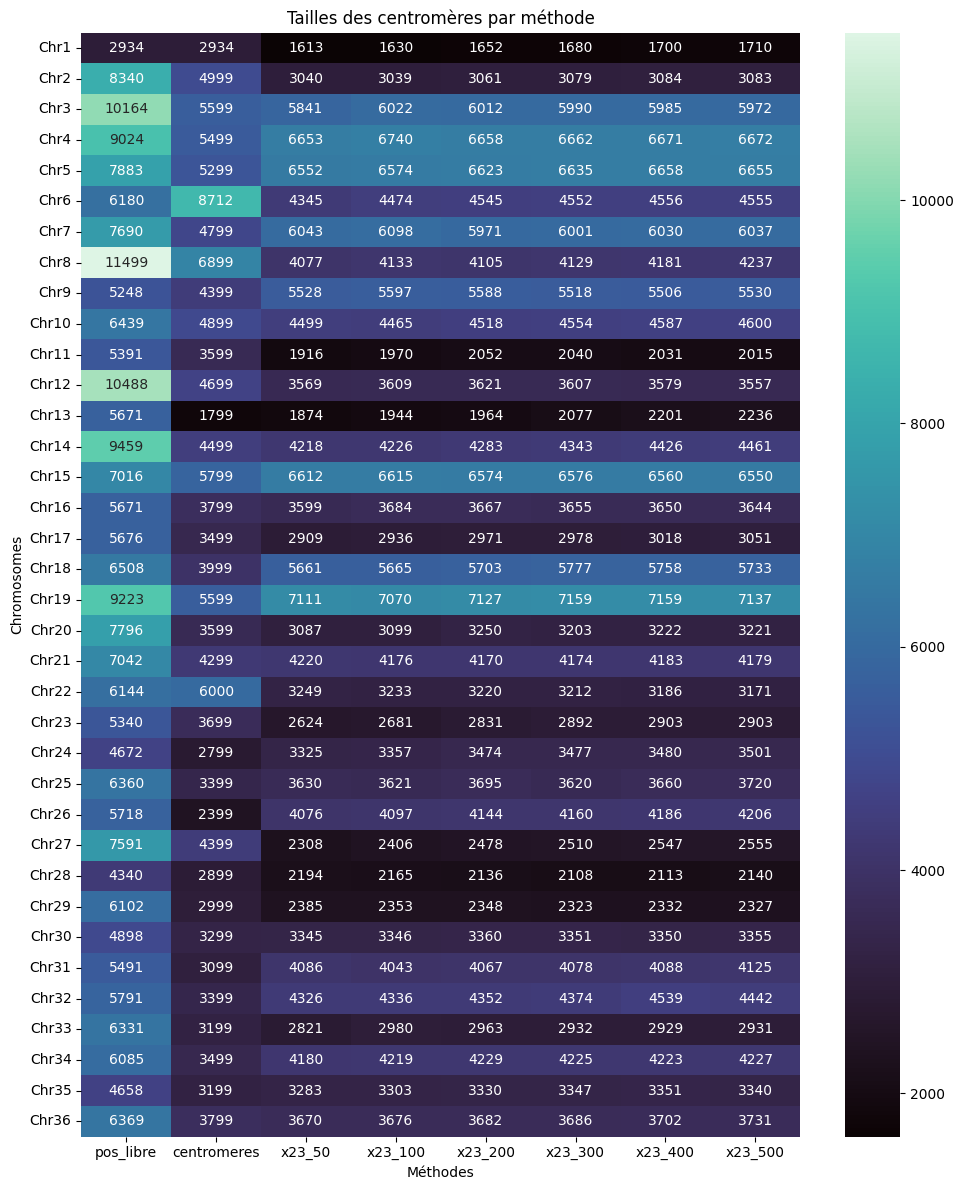

In [3]:
import seaborn as sns

lengths = []
for i in range(1,37):
    cent_start, cent_end = pos_libre[i]
    lengths.append(cent_end-cent_start)

lengths_0 = []
for i in range(1,37):
    cent_start, cent_end = centromeres[str(i)]
    lengths_0.append(cent_end-cent_start)

lengths_1 = [length for (_, _, length) in x23_50.values()]
lengths_2 = [length for (_, _, length) in x23_100.values()]
lengths_3 = [length for (_, _, length) in x23_200.values()]
lengths_4 = [length for (_, _, length) in x23_300.values()]
lengths_5 = [length for (_, _, length) in x23_400.values()]
lengths_6 = [length for (_, _, length) in x23_500.values()]





# 1. Construire la table de données
chromosomes = [f'Chr{i}' for i in range(1, 37)]
methodes = ['pos_libre', 'centromeres', 'x23_50', 'x23_100', 'x23_200', 'x23_300','x23_400','x23_500']

# 2. Créer un DataFrame
df = pd.DataFrame({
    'pos_libre': lengths,
    'centromeres': lengths_0,
    'x23_50': lengths_1,
    'x23_100': lengths_2,
    'x23_200': lengths_3,
    'x23_300': lengths_4,
    'x23_400': lengths_5,
    'x23_500': lengths_6


}, index=chromosomes)

# 3. Afficher la heatmap
plt.figure(figsize=(10, 12))
sns.heatmap(df, annot=True, fmt='d', cmap='mako')
plt.title("Tailles des centromères par méthode")
plt.xlabel("Méthodes")
plt.ylabel("Chromosomes")
plt.tight_layout()
plt.show()

In [2]:
print(len(data[0][35]))

2672151


In [9]:
import pickle
with open("homopolymere50_400.pkl", "wb") as f:
    pickle.dump(data, f)

In [7]:
import pickle
with open("Trall.pkl", "wb") as f:
    pickle.dump(data, f)

In [5]:
import pickle

with open("homopolymere50_400.pkl", "rb") as f:
    data = pickle.load(f)

In [1]:
import pickle

with open("Trall.pkl", "rb") as f:
    data = pickle.load(f)
    
print(len(data))

print(len(data))



6
6


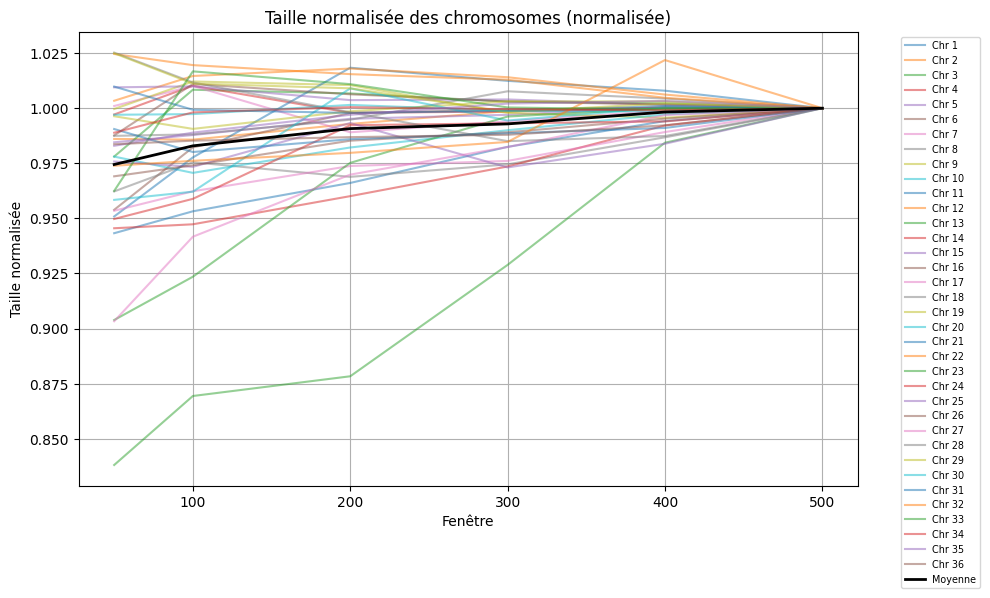

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Tes données par fenêtre
lengths_1 = [length for (_, _, length) in x23_50.values()]
lengths_2 = [length for (_, _, length) in x23_100.values()]
lengths_3 = [length for (_, _, length) in x23_200.values()]
lengths_4 = [length for (_, _, length) in x23_300.values()]
lengths_5 = [length for (_, _, length) in x23_400.values()]
lengths_6 = [length for (_, _, length) in x23_500.values()]

# Combiner en matrice (36 chromosomes × 5 fenêtres)
temp_data = np.array([lengths_1, lengths_2, lengths_3, lengths_4, lengths_5,lengths_6]).T  # shape: (36, 5)

# Normalisation par la dernière fenêtre (lengths_5)
data_norm = temp_data / temp_data[:, -1][:, np.newaxis]  # Broadcasting

# Fenêtres utilisées (en kb)
windows = [50, 100, 200, 300, 400,500]

# Tracer chaque chromosome
plt.figure(figsize=(10, 6))
for i in range(data_norm.shape[0]):
    plt.plot(windows, data_norm[i], alpha=0.5, label=f'Chr {i+1}')

# Tracer la moyenne
mean_curve = np.mean(data_norm, axis=0)
plt.plot(windows, mean_curve, color='black', linewidth=2, label='Moyenne')

plt.xlabel("Fenêtre")
plt.ylabel("Taille normalisée")
plt.title("Taille normalisée des chromosomes (normalisée)")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')
plt.tight_layout()
plt.show()


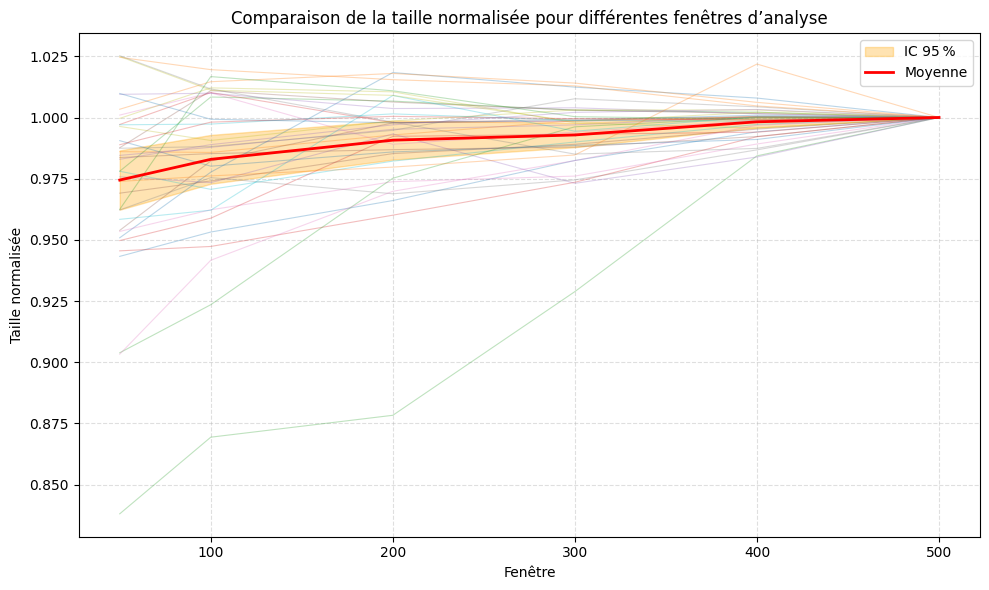

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 1. Récupération des longueurs par fenêtre ------------------------------
def lengths_from(d):
    """Extrait la 3ᵉ valeur (length) des tuples contenus dans le dict `d`."""
    return [length for (_, _, length) in d.values()]

windows = [50, 100, 200, 300, 400, 500]          # en kb, ordre croissant

length_arrays = [
    lengths_from(x23_50),
    lengths_from(x23_100),
    lengths_from(x23_200),
    lengths_from(x23_300),
    lengths_from(x23_400),
    lengths_from(x23_500),
]

# ---- 2. Matrice (36 × 6) et normalisation -----------------------------------
temp_data = np.array(length_arrays).T           
data_norm  = temp_data / temp_data[:, -1][:, None] 

# ---- 3. Moyenne & intervalle de confiance -----------------------------------
mean_curve = data_norm.mean(axis=0)
std_curve  = data_norm.std(axis=0, ddof=1)
n          = data_norm.shape[0]                  # nb de chromosomes
se_curve   = std_curve / np.sqrt(n)              # erreur‑type
ci95_upper = mean_curve + 1.96 * se_curve
ci95_lower = mean_curve - 1.96 * se_curve

# ---- 4. Tracé ----------------------------------------------------------------
plt.figure(figsize=(10, 6))

# courbes individuelles (transparence légère)
for chrom in data_norm:
    plt.plot(windows, chrom, alpha=0.3, linewidth=0.8)

# enveloppe de confiance ±95 %
plt.fill_between(windows, ci95_lower, ci95_upper,
                 color='orange', alpha=0.3, label='IC 95 %')

# courbe moyenne
plt.plot(windows, mean_curve, color='red', linewidth=2, label='Moyenne')

plt.xlabel("Fenêtre")
plt.ylabel("Taille normalisée")
plt.title("Comparaison de la taille normalisée pour différentes fenêtres d’analyse")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig("taille_normalisee.png", dpi=300)
plt.show()


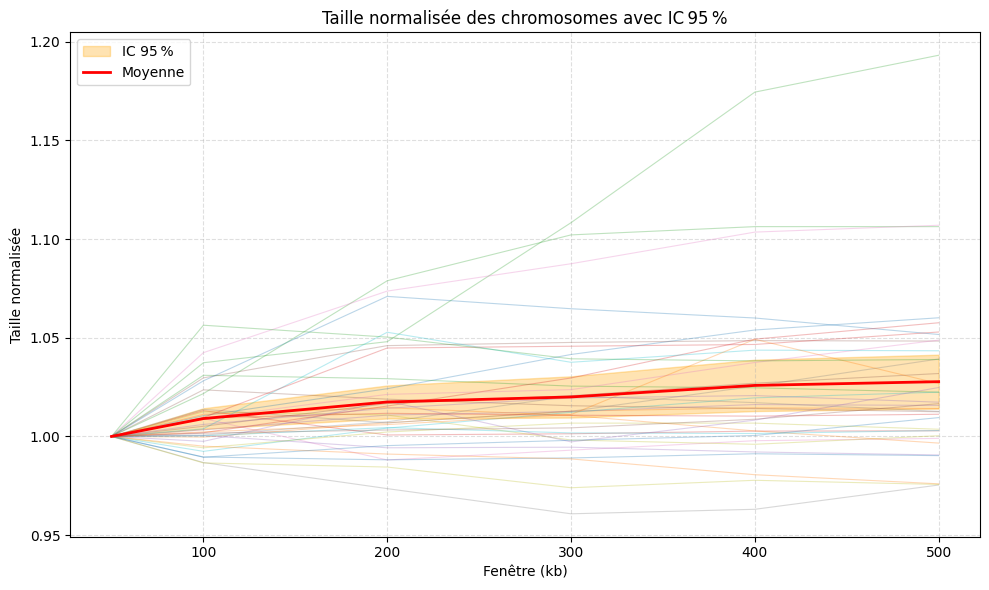

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 1. Récupération des longueurs par fenêtre ------------------------------
def lengths_from(d):
    """Extrait la 3ᵉ valeur (length) des tuples contenus dans le dict `d`."""
    return [length for (_, _, length) in d.values()]

windows = [50, 100, 200, 300, 400, 500]          # en kb, ordre croissant

length_arrays = [
    lengths_from(x23_50),
    lengths_from(x23_100),
    lengths_from(x23_200),
    lengths_from(x23_300),
    lengths_from(x23_400),
    lengths_from(x23_500),
]

# ---- 2. Matrice (36 × 6) et normalisation -----------------------------------
temp_data = np.array(length_arrays).T           
data_norm  = temp_data / temp_data[:, 0][:, None] 

# ---- 3. Moyenne & intervalle de confiance -----------------------------------
mean_curve = data_norm.mean(axis=0)
std_curve  = data_norm.std(axis=0, ddof=1)
n          = data_norm.shape[0]                  # nb de chromosomes
se_curve   = std_curve / np.sqrt(n)              # erreur‑type
ci95_upper = mean_curve + 1.96 * se_curve
ci95_lower = mean_curve - 1.96 * se_curve

# ---- 4. Tracé ----------------------------------------------------------------
plt.figure(figsize=(10, 6))

# courbes individuelles (transparence légère)
for chrom in data_norm:
    plt.plot(windows, chrom, alpha=0.3, linewidth=0.8)

# enveloppe de confiance ±95 %
plt.fill_between(windows, ci95_lower, ci95_upper,
                 color='orange', alpha=0.3, label='IC 95 %')

# courbe moyenne
plt.plot(windows, mean_curve, color='red', linewidth=2, label='Moyenne')

plt.xlabel("Fenêtre (kb)")
plt.ylabel("Taille normalisée")
plt.title("Taille normalisée des chromosomes avec IC 95 %")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


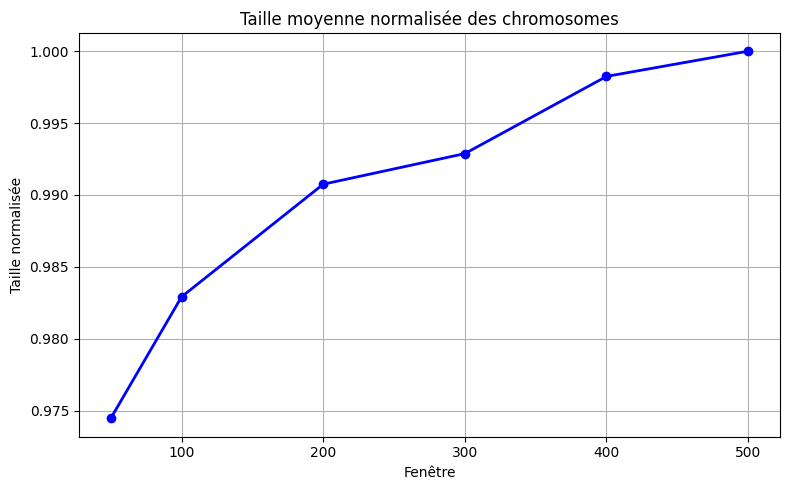

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Tes données
lengths_1 = [length for (_, _, length) in x23_50.values()]
lengths_2 = [length for (_, _, length) in x23_100.values()]
lengths_3 = [length for (_, _, length) in x23_200.values()]
lengths_4 = [length for (_, _, length) in x23_300.values()]
lengths_5 = [length for (_, _, length) in x23_400.values()]
lengths_6 = [length for (_, _, length) in x23_500.values()]

# Construction de la matrice (chromosomes × fenêtres)
temp_data = np.array([lengths_1, lengths_2, lengths_3, lengths_4, lengths_5,lengths_6]).T

# Normalisation par la dernière colonne (400)
data_norm = temp_data / temp_data[:, -1][:, np.newaxis]

# Moyenne sur les chromosomes
mean_curve = np.mean(data_norm, axis=0)

# Fenêtres utilisées 
windows = [50, 100, 200, 300, 400,500]

# Tracé de la courbe moyenne
plt.figure(figsize=(8, 5))
plt.plot(windows, mean_curve, marker='o', color='blue', linewidth=2)
plt.xlabel("Fenêtre")
plt.ylabel("Taille normalisée")
plt.title("Taille moyenne normalisée des chromosomes")
plt.grid(True)
plt.tight_layout()
plt.show()


In [22]:
df = pd.read_csv("../data/Centromere_Positions/centromeres.csv")
centromeres = {
    row['Chromosome']: (row['Centromere_Start'], row['Centromere_End'])
    for _, row in df.iterrows()
}

vecteur_debut = []
vecteur_fin = []

temp = data[4]
for temp in data:
    for i in range(0,36):
        temp_ =  temp[i]['X2_X3']
        #200
        mean = np.mean(temp_)
        if i == 6:
            
        peaks, properties = find_peaks(temp_,  prominence=mean*2, distance=20)
    
        window = 3000
        #Moyenne
        peak_medians = []
        for peak in peaks:
            start = max(0, peak - window//2)
            end = min(len(temp_), peak + window//2)
            mean_val = np.mean(temp_[start:end])
            peak_medians.append((peak, mean_val))
        
        # Trouver le pic avec la médiane la plus élevée
        if peak_medians:
            peak_max, max_median = max(peak_medians, key=lambda x: x[1])
            max_index = peak_max
    
    
            # Centromères
            if str(i+1) in centromeres:
                cent_start, cent_end = centromeres[str(i+1)]
                cent_start = (cent_start )-6500
                cent_end=(cent_end )-3500
                if cent_start <= max_index <= cent_end: 
                    print(f'{i+1} : validé : Commence {max_index} ')
                else:
                    print(f'{i+1} : {max_index}')

1 : validé : Commence 253643 
2 : validé : Commence 261046 
3 : validé : Commence 244558 
4 : validé : Commence 123877 
5 : validé : Commence 361316 
6 : validé : Commence 121237 
7 : validé : Commence 206226 
8 : validé : Commence 483322 
9 : validé : Commence 271070 
10 : validé : Commence 292897 
11 : validé : Commence 155401 
12 : validé : Commence 283921 
13 : validé : Commence 139477 
14 : validé : Commence 154571 
15 : validé : Commence 322563 
16 : validé : Commence 335747 
17 : validé : Commence 338814 
18 : validé : Commence 442251 
19 : validé : Commence 619217 
20 : validé : Commence 519987 
21 : validé : Commence 222838 
22 : validé : Commence 604289 
23 : validé : Commence 547536 
24 : validé : Commence 461771 
25 : validé : Commence 585308 
26 : validé : Commence 603443 
27 : validé : Commence 979720 
28 : validé : Commence 818665 
29 : validé : Commence 337402 
30 : validé : Commence 226470 
31 : validé : Commence 774232 
32 : validé : Commence 1164559 
33 : validé : Co

In [ ]:

vecteur_Debut = []
vecteur_Fin = []

vecteur_longeur = []

df = pd.read_csv("../data/Centromere_Positions/pos_libre.csv")
pos_libre = {
    int(row.Chromosome): (int(row.Start), int(row.End))
    for row in df.itertuples(index=False)
}
df = pd.read_csv("../data/Centromere_Positions/centromeres.csv")
centromeres = {
    row['Chromosome']: (row['Centromere_Start'], row['Centromere_End'])
    for _, row in df.iterrows()
}

g = 0
#data = dataLV39c5
#data = dataFriedlin2021

for temp in data:
    vecteur_rate = []
    for i in range(0,36):
        temp_ =  temp[i]['X2_X3']
    

    
        mean = np.mean(temp_)
    
        peaks, properties = find_peaks(temp_,  prominence=mean*2, distance=20)
    
        window = 3000
        peak_medians = []
    
     
    
    
    
            #Moyenne
        peak_means = []
        for peak in peaks:
            start = max(0, peak - window//2)
            end = min(len(temp_), peak + window//2)
            mean_val = np.mean(temp_[start:end])
            peak_medians.append((peak, mean_val))
        
      #  for peak in peaks:
      #      start = max(0, peak - window//2)
      #      end = min(len(temp_), peak + window//2 + 1)
        
       #     neighborhood = temp_[start:end]
       #     if len(neighborhood) > 0:
       #         median_val = np.median(neighborhood)
       #         peak_medians.append((peak, median_val))
        
        # Trouver le pic avec la médiane la plus élevée
        if peak_medians:
            peak_max, max_median = max(peak_medians, key=lambda x: x[1])
            max_index = peak_max
    
    
            #Chercher la taille du centromere
    
    
            # Appliquer un filtre pour lisser
            temp_X2_3 = uniform_filter1d(temp_, size=1500)
            temp_X2_3 = temp_X2_3[max_index-25000:max_index+25000]
            
    
            
            # Détection des pics
            peaks, properties = find_peaks(temp_X2_3, prominence=5, distance=200)
    
                
            # Trouver le pic avec la plus grande **prominence**
            if len(peaks) > 0:
                prominences = properties['prominences']
                peak_index = np.argmax(prominences)
                peak_max = peaks[peak_index]
            
                # Calcule la largeur du pic à mi-hauteur
                widths_result = peak_widths(temp_X2_3, peaks, rel_height=0.4)
            
                taille = widths_result[0][peak_index]
                seuil =  widths_result[1][peak_index]

                debut = widths_result[2][peak_index]
                fin = widths_result[3][peak_index]

                debut = int(debut)
                fin = int(fin)
                
                marge = 750
                finish = True
                distance = []
                temp_fin = []
                while finish:
                    
                    recherche = False
                    limiteFin = min(len(temp_X2_3), fin + marge)
                    pos = fin

                    while pos < limiteFin and recherche == False:
                        if  temp_X2_3[pos] > seuil:
                            recherche = True
                        pos += 1
                    if recherche == True:
                         temp_fin.append(fin)
                         distance.append(0)
                         while pos + 1 < len(temp_X2_3) and temp_X2_3[pos] > seuil:
                            pos += 1
                            distance[len(distance)-1] += 1

                         fin = pos
                    else: 
                        finish = False

                t = len(distance)-1
                while t >= 0 and distance[t] < 200:
                    fin = temp_fin[t]
                    t = t -1 
                #Avant
                finish = True
                distance = 0
                distance = []
                temp_debut = []

                while finish:
                    recherche = False
                    limiteDebut = max(0, debut - marge)
                    pos = debut
                    while pos > limiteDebut and recherche == False:
     
                        if  temp_X2_3[pos] > seuil:
                            recherche = True
                        pos -= 1
            
                    if recherche == True:
                         temp_debut.append(debut)
                         distance.append(0)

                         while pos + 1 < len(temp_X2_3) and temp_X2_3[pos] > seuil:
                            pos -= 1
                            distance[len(distance)-1] += 1
                         debut = pos
                    else:
                        finish = False


                t = len(distance)-1
                while t >= 0 and distance[t] < 200:
                    debut = temp_debut[t]
                    t = t -1 
                    
                debut = debut+max_index-25000+5000
                fin = fin+max_index-25000+5000
                debut = int(debut)
                fin = int(fin)
                max_index = max_index+5000
                # Affichage
    
                taille = fin - debut
    
                if i == 19 and g == 2:
                    #temp_X2_3 = uniform_filter1d(temp_, size=1500)
                    print(f'Longeur du chrom {len(temp_)}' )
                    # Initialiser la figure
                    fig = go.Figure()
                    
                    # Ajouter la courbe
                    fig.add_trace(go.Scatter(
                        y=temp_,
                        mode='lines',
                        name='Erreur normalisée'
                    ))
                    
                      # Tracer la largeur à mi-hauteur
                    mi_hauteur = temp_X2_3[peak_max] / 2  # ou une autre valeur si tu la connais précisément
                    fig.add_trace(go.Scatter(
                        x=[debut-max_index+25000, fin-max_index+25000],
                        y=[seuil]*2,
                        mode='lines',
                        line=dict(color='green', dash='dash'),
                        name='Largeur à mi-hauteur'
                    ))

                    #if str(i) in centromeres:
                     #   cent_start, cent_end = centromeres[str(i)]
                     #   fig.add_vline(x=(debut)-5000, line=dict(color='red', dash='dash'), name='Centromere Start')
                     #   fig.add_vline(x=(fin)-5000, line=dict(color='purple', dash='dash'), name='Centromere End')
                     #   fig.add_vline(x=(max_index)-30000, line=dict(color='black', dash='dash'), name='pic')
                     #   fig.add_vline(x=(peak_max)+max_index-30000-5000, line=dict(color='green', dash='dash'), name='pic')
                    if str(i+1) in centromeres:
                        cent_start, cent_end = centromeres[str(i+1)]
                        fig.add_vline(x=(debut)-5000, line=dict(color='red', dash='dash'), name='Centromere Start')
                        fig.add_vline(x=(fin)-5000, line=dict(color='purple', dash='dash'), name='Centromere End')
                        #fig.add_vline(x=(max_index)-max_index+25000, line=dict(color='black', dash='dash'), name='pic')
                        #fig.add_vline(x=(peak_max), line=dict(color='green', dash='dash'), name='pic')


                    fig.update_layout(
                        title=f"Karlin - Chromosome {i+1}",
                        xaxis_title="",
                        yaxis_title="",
                        legend=dict(orientation="h")
                    )
                    fig.show()


                       # Initialiser la figure
                    fig = go.Figure()
                    
                    # Ajouter la courbe
                    fig.add_trace(go.Scatter(
                        y=temp_X2_3,
                        mode='lines',
                        name='Erreur normalisée'
                    ))
                    fig.show()

                    print(f'{i+1} : Commence {debut}    Fini {fin}  Taille : {taille}')


                        
                if i+1 in pos_libre:
                    pos_start, pos_end = pos_libre[i+1]
                    if debut-pos_start < 0 or pos_end-fin < 0:
                        vecteur_rate.append(i+1)
                    
                    print(f'{i+1} : Commence {debut-pos_start}    Fini {pos_end-fin}  Taille : {taille}')
    g = g+1
    
                    #print(f'{i+1} : Commence {debut}    Fini {fin}  Taille : {taille}')
    print(vecteur_rate)
    
    
    

In [66]:
print(len(temp_X2_3))
temp_X2_3 = []

50000


In [ ]:
df = pd.read_csv("../data/Centromere_Positions/pos_libre.csv")
pos_libre = {
    int(row.Chromosome): (int(row.Start), int(row.End))
    for row in df.itertuples(index=False)
}

df = pd.read_csv("../data/Centromere_Positions/centromeres.csv")
centromeres = {
    row['Chromosome']: (row['Centromere_Start'], row['Centromere_End'])
    for _, row in df.iterrows()
}



vecteur_Debut = []
vecteur_Fin = []

vecteur_longeur = []
window_lsit= [50,100,200,300,400]

g = 0

for genome in data:
    vecteur_Debut = []
    vecteur_Fin = []
    
    vecteur_longeur = []
    for i in range(0,36):
        temp_ =  genome[i]['X2_X3']
        if g ==1:
            mean = np.mean(temp_)
        
            peaks, properties = find_peaks(temp_,  prominence=mean*2, distance=20)
        
            window = 3000
            peak_medians = []
        
         
        
        
        
                #Moyenne
            peak_means = []
            for peak in peaks:
                start = max(0, peak - window//2)
                end = min(len(temp_), peak + window//2)
                mean_val = np.mean(temp_[start:end])
                peak_medians.append((peak, mean_val))
        
            
            # Trouver le pic avec la médiane la plus élevée
            if peak_medians:
                peak_max, max_median = max(peak_medians, key=lambda x: x[1])
                max_index = peak_max
        
        
                #Chercher la taille du centromere
        
        
                # Appliquer un filtre pour lisser
                temp_X2_3 = uniform_filter1d(temp_, size=3000)
                temp_X2_3 = temp_X2_3[max_index-10000:max_index+10000]
                #temp_X2_3 = temp_X2_3[max_index-30000:max_index+25000]
    
        
                
                # Détection des pics
                peaks, properties = find_peaks(temp_X2_3, prominence=5, distance=200)
        
                    
                # Trouver le pic avec la plus grande **prominence**
                if len(peaks) > 0:
                    prominences = properties['prominences']
                    peak_index = np.argmax(prominences)
                    peak_max = peaks[peak_index]
                
                    # Calcule la largeur du pic à mi-hauteur
                    widths_result = peak_widths(temp_X2_3, peaks, rel_height=0.4)
                
                    taille = widths_result[0][peak_index]
                    debut = widths_result[2][peak_index]
                    fin = widths_result[3][peak_index]
        
                    debut = debut+max_index-10000+5000
                    fin = fin+max_index-10000+5000
                    debut = int(debut)
                    fin = int(fin)
                    max_index = max_index+5000
                    # Affichage
        
        
        
              
                    print(f'{i+1} : Commence {debut}    Fini {fin}  Taille : {taille}')
           
                    if i == 6:
                        #temp_X2_3 = uniform_filter1d(temp_, size=1500)
    
                        # Initialiser la figure
                        fig = go.Figure()
                        
                        # Ajouter la courbe
                        fig.add_trace(go.Scatter(
                            y=temp_X2_3,
                            mode='lines',
                            name='Erreur normalisée'
                        ))
                        
                  
                        
                        if str(i) in centromeres:
                            cent_start, cent_end = centromeres[str(i)]
                            fig.add_vline(x=(debut)-max_index+10000, line=dict(color='red', dash='dash'), name='Centromere Start')
                            fig.add_vline(x=(fin)-max_index+10000, line=dict(color='purple', dash='dash'), name='Centromere End')
                            fig.add_vline(x=(max_index)-max_index+10000, line=dict(color='black', dash='dash'), name='pic')
                            fig.add_vline(x=(peak_max), line=dict(color='green', dash='dash'), name='pic')
    
    
                        fig.update_layout(
                            title=f"Karlin - Chromosome {i+1}",
                            xaxis_title="",
                            yaxis_title="",
                            legend=dict(orientation="h")
                        )
                        fig.show()
    

    
    print(len(vecteur_Debut))

    g = g +1

In [85]:
df = pd.read_csv("../data/Centromere_Positions/pos_libre.csv")
pos_libre = {
    int(row.Chromosome): (int(row.Start), int(row.End))
    for row in df.itertuples(index=False)
}

vecteur_Debut = []
vecteur_Fin = []
vecteur_longeur = []
window_lsit= [50,100,200,300,400]

g = 0

for genome in data:
    vecteur_Debut = []
    vecteur_Fin = []
    vecteur_rate = []

    vecteur_longeur = []
    for i in range(0,36):
        temp_ =  genome[i]['X2_X3']
    
        mean = np.mean(temp_)
    
        peaks, properties = find_peaks(temp_,  prominence=mean*2, distance=20)
    
        window = 3000
        peak_medians = []
    
     
    
    
    
            #Moyenne
        peak_means = []
        for peak in peaks:
            start = max(0, peak - window//2)
            end = min(len(temp_), peak + window//2)
            mean_val = np.mean(temp_[start:end])
            peak_medians.append((peak, mean_val))
    
        
        # Trouver le pic avec la médiane la plus élevée
        if peak_medians:
            peak_max, max_median = max(peak_medians, key=lambda x: x[1])
            max_index = peak_max
    
    
            #Chercher la taille du centromere
    
            # Appliquer un filtre pour lisser
            temp_X2_3 = uniform_filter1d(temp_, size=1500)

            
            # 2. Détection de tous les pics
            peaks, properties = find_peaks(temp_X2_3, prominence=5, distance=200)
            
            # 3. Filtrage des pics dans une fenêtre autour de max_index
            window_size = 25000
            start = max(0, max_index - window_size)
            end = min(len(temp_X2_3), max_index + window_size)
            
            # 4. Garder seulement les pics dans la zone souhaitée
            zone_peaks = [p for p in peaks if start <= p <= end]
            zone_properties = {k: v[[i for i, p in enumerate(peaks) if start <= p <= end]] for k, v in properties.items()}
                
            # Trouver le pic avec la plus grande **prominence**
           

            if len(zone_peaks) > 0:
                prominences = zone_properties['prominences']
                
                # Trouve l'index du pic avec la plus grande prominence
                peak_index = np.argmax(prominences)
                peak_max = zone_peaks[peak_index]
                # Calcule la largeur du pic à mi-hauteur dans toute la série
                widths_result = peak_widths(temp_X2_3, [peak_max], rel_height=0.4)
            
                taille = widths_result[0][0]
                debut = widths_result[2][0]
                fin = widths_result[3][0]
    
                debut = debut+5000
                fin = fin+5000
                debut = int(debut)
                fin = int(fin)
                max_index = max_index+5000
                # Affichage
    
    

    
    
                vecteur_Debut.append(debut)
                vecteur_Fin.append(fin)
                vecteur_longeur.append(taille)
    
    
    print(vecteur_rate)
    
    #result = pd.DataFrame()
    #result['Chromosome'] = list(range(1, 37))
    #result['start'] = vecteur_Debut 
    #result['end'] = vecteur_Fin
    #result['length'] = vecteur_longeur
    #result.to_csv(f"../output/estimation/X2X3/{window_lsit[g]}_X2_X3_M2.csv", index=False)
    g = g +1

1 : Commence 257142    Fini 258755  Taille : 1613.0
2 : Commence 264495    Fini 268707  Taille : 4212.1999999999825
3 : Commence 246982    Fini 253075  Taille : 6093.0
4 : Commence 125495    Fini 132269  Taille : 6774.200000000012
5 : Commence 362861    Fini 367359  Taille : 4497.800000000047
6 : Commence 124720    Fini 127471  Taille : 2751.0
7 : Commence 208212    Fini 212189  Taille : 3976.7999999999884
8 : Commence 487213    Fini 491599  Taille : 4386.0
9 : Commence 271602    Fini 277352  Taille : 5749.400000000023
10 : Commence 295848    Fini 299913  Taille : 4065.5999999999767
11 : Commence 159588    Fini 161854  Taille : 2265.7999999999884
12 : Commence 287077    Fini 291010  Taille : 3932.8000000000466
13 : Commence 143541    Fini 145517  Taille : 1976.0
14 : Commence 158324    Fini 162612  Taille : 4288.599999999977
15 : Commence 322933    Fini 329670  Taille : 6736.800000000047
16 : Commence 339995    Fini 343924  Taille : 3929.5999999999767
17 : Commence 341003    Fini 34418

In [ ]:

vecteur_Debut = []
vecteur_Fin = []

vecteur_longeur = []

df = pd.read_csv("../data/Centromere_Positions/pos_libre.csv")
pos_libre = {
    int(row.Chromosome): (int(row.Start), int(row.End))
    for row in df.itertuples(index=False)
}
df = pd.read_csv("../data/Centromere_Positions/centromeres.csv")
centromeres = {
    row['Chromosome']: (row['Centromere_Start'], row['Centromere_End'])
    for _, row in df.iterrows()
}

g = 0
#data = dataLV39c5
#data = dataFriedlin2021

for temp in data:
    vecteur_rate = []
    for i in range(0,36):
        temp_ =  temp[i]['X2_X3']
    

        if g == 1:
            mean = np.mean(temp_)
        
            peaks, properties = find_peaks(temp_,  prominence=mean*2, distance=20)
        
            window = 3000
            peak_medians = []
        
         
        
        
        
                #Moyenne
            peak_means = []
            for peak in peaks:
                start = max(0, peak - window//2)
                end = min(len(temp_), peak + window//2)
                mean_val = np.mean(temp_[start:end])
                peak_medians.append((peak, mean_val))
            
          #  for peak in peaks:
          #      start = max(0, peak - window//2)
          #      end = min(len(temp_), peak + window//2 + 1)
            
           #     neighborhood = temp_[start:end]
           #     if len(neighborhood) > 0:
           #         median_val = np.median(neighborhood)
           #         peak_medians.append((peak, median_val))
            
            # Trouver le pic avec la médiane la plus élevée
            if peak_medians:
                peak_max, max_median = max(peak_medians, key=lambda x: x[1])
                max_index = peak_max
        
        
                #Chercher la taille du centromere
        
        
                # Appliquer un filtre pour lisser
                temp_X2_3 = uniform_filter1d(temp_, size=1500)
                temp_X2_3 = temp_X2_3[max_index-25000:max_index+25000]
                
        
                
                # Détection des pics
                peaks, properties = find_peaks(temp_X2_3, prominence=5, distance=200)
        
                    
                # Trouver le pic avec la plus grande **prominence**
                if len(peaks) > 0:
                    prominences = properties['prominences']
                    peak_index = np.argmax(prominences)
                    peak_max = peaks[peak_index]
                
                    # Calcule la largeur du pic à mi-hauteur
                    widths_result = peak_widths(temp_X2_3, peaks, rel_height=0.4)
                
                    taille = widths_result[0][peak_index]
                    jpp =  widths_result[1][peak_index]
    
                    debut = widths_result[2][peak_index]
                    fin = widths_result[3][peak_index]
        
                    debut = debut+max_index-25000+5000
                    fin = fin+max_index-25000+5000
                    debut = int(debut)
                    fin = int(fin)
                    max_index = max_index+5000
                    # Affichage
        
        
        
              
                    #temp_X2_3 = uniform_filter1d(temp_, size=1500)

                    # Initialiser la figure
                    fig = go.Figure()
                    
                    # Ajouter la courbe
                    fig.add_trace(go.Scatter(
                        y=temp_X2_3,
                        mode='lines',
                        name='Erreur normalisée'
                    ))
                    
                      # Tracer la largeur à mi-hauteur
                    mi_hauteur = temp_X2_3[peak_max] / 2  # ou une autre valeur si tu la connais précisément
                
                    fig.add_trace(go.Scatter(
                        x=[debut-max_index+25000, fin-max_index+25000],
                        y=[jpp]*2,
                        mode='lines',
                        line=dict(color='green', dash='dash'),
                        name='Largeur à mi-hauteur'
                    ))
                    
                    #if str(i) in centromeres:
                     #   cent_start, cent_end = centromeres[str(i)]
                     #   fig.add_vline(x=(debut)-5000, line=dict(color='red', dash='dash'), name='Centromere Start')
                     #   fig.add_vline(x=(fin)-5000, line=dict(color='purple', dash='dash'), name='Centromere End')
                     #   fig.add_vline(x=(max_index)-30000, line=dict(color='black', dash='dash'), name='pic')
                     #   fig.add_vline(x=(peak_max)+max_index-30000-5000, line=dict(color='green', dash='dash'), name='pic')
                    if str(i+1) in centromeres:
                        cent_start, cent_end = centromeres[str(i+1)]
                        fig.add_vline(x=(debut)-max_index+25000, line=dict(color='red', dash='dash'), name='Centromere Start')
                        fig.add_vline(x=(fin)-max_index+25000, line=dict(color='purple', dash='dash'), name='Centromere End')
                        fig.add_vline(x=(max_index)-max_index+25000, line=dict(color='black', dash='dash'), name='pic')
                        fig.add_vline(x=(peak_max), line=dict(color='green', dash='dash'), name='pic')


                    fig.update_layout(
                        title=f"X2-3 - Chromosome {i+1}",
                        xaxis_title="",
                        yaxis_title="",
                        legend=dict(orientation="h")
                    )
                    fig.write_image(f"test/X2-X3_chromosome_{i+1}.png")
                    fig.show()
                    
                    print(f'{i+1} : Commence {debut}    Fini {fin}  Taille : {taille}')

    
                            
                    if i+1 in pos_libre:
                        pos_start, pos_end = pos_libre[i+1]
                        if debut-pos_start < 0 or pos_end-fin < 0:
                            vecteur_rate.append(i+1)
                        
                        print(f'{i+1} : Commence {debut-pos_start}    Fini {pos_end-fin}  Taille : {taille}')
               
        
    g = g+1                    #print(f'{i+1} : Commence {debut}    Fini {fin}  Taille : {taille}')
    print(vecteur_rate)
    
    
    

In [51]:
#Creation du fichier avec reduction + seuil apres et avant



vecteur_Debut = []
vecteur_Fin = []

vecteur_longeur = []
window_lsit= [50,100,200,300,400,500]

g = 0

for genome in data:
    vecteur_Debut = []
    vecteur_Fin = []
    
    vecteur_longeur = []
    for i in range(0,36):
        temp_ =  genome[i]['X2_X3']
    
        mean = np.mean(temp_)
    
        peaks, properties = find_peaks(temp_,  prominence=mean*2, distance=20)
    
        window = 3000
        peak_medians = []
    
     
    
    
    
            #Moyenne
        peak_means = []
        for peak in peaks:
            start = max(0, peak - window//2)
            end = min(len(temp_), peak + window//2)
            mean_val = np.mean(temp_[start:end])
            peak_medians.append((peak, mean_val))
    
        
        # Trouver le pic avec la médiane la plus élevée
        if peak_medians:
            peak_max, max_median = max(peak_medians, key=lambda x: x[1])
            max_index = peak_max
    
    
            #Chercher la taille du centromere
    
    
            # Appliquer un filtre pour lisser
            temp_X2_3 = uniform_filter1d(temp_, size=1500)
            temp_X2_3 = temp_X2_3[max_index-25000:max_index+25000]
            
    
            
            # Détection des pics
            peaks, properties = find_peaks(temp_X2_3, prominence=5, distance=200)
    
                
            # Trouver le pic avec la plus grande **prominence**
            if len(peaks) > 0:
                prominences = properties['prominences']
                peak_index = np.argmax(prominences)
                peak_max = peaks[peak_index]
            
                # Calcule la largeur du pic à mi-hauteur
                widths_result = peak_widths(temp_X2_3, peaks, rel_height=0.4)
                seuil = widths_result[1][peak_index]
                taille = widths_result[0][peak_index]
                debut = widths_result[2][peak_index]
                fin = widths_result[3][peak_index]



                debut = int(debut)
                fin = int(fin)
                
                marge = 750
                finish = True
                distance = []
                temp_fin = []
                while finish:
                    
                    recherche = False
                    limiteFin = min(len(temp_X2_3), fin + marge)
                    pos = fin

                    while pos < limiteFin and recherche == False:
                        if  temp_X2_3[pos] > seuil:
                            recherche = True
                        pos += 1
                    if recherche == True:
                         temp_fin.append(fin)
                         distance.append(0)
                         while pos + 1 < len(temp_X2_3) and temp_X2_3[pos] > seuil:
                            pos += 1
                            distance[len(distance)-1] += 1

                         fin = pos
                    else: 
                        finish = False

                t = len(distance)-1
                while t >= 0 and distance[t] < 200:
                    fin = temp_fin[t]
                    t = t -1 
                #Avant
                finish = True
                distance = 0
                distance = []
                temp_debut = []

                while finish:
                    recherche = False
                    limiteDebut = max(0, debut - marge)
                    pos = debut
                    while pos > limiteDebut and recherche == False:
     
                        if  temp_X2_3[pos] > seuil:
                            recherche = True
                        pos -= 1
            
                    if recherche == True:
                         temp_debut.append(debut)
                         distance.append(0)

                         while pos + 1 < len(temp_X2_3) and temp_X2_3[pos] > seuil:
                            pos -= 1
                            distance[len(distance)-1] += 1
                         debut = pos
                    else:
                        finish = False


                t = len(distance)-1
                while t >= 0 and distance[t] < 200:
                    debut = temp_debut[t]
                    t = t -1 
                    
                debut = debut+max_index-25000+5000
                fin = fin+max_index-25000+5000
                debut = int(debut)
                fin = int(fin)
                max_index = max_index+5000
                taille = fin - debut
                # Affichage
    
    
    
          
                print(f'{i+1} : Commence {debut}    Fini {fin}  Taille : {taille}')
       
                                
           

    
                vecteur_Debut.append(debut)
                vecteur_Fin.append(fin)
                vecteur_longeur.append(taille)
    
    
    print(len(vecteur_Debut))
    result = pd.DataFrame()
    result['Chromosome'] = list(range(1, 37))
    result['start'] = vecteur_Debut 
    result['end'] = vecteur_Fin
    result['length'] = vecteur_longeur
    result.to_csv(f"../output/estimation/X2X3/{window_lsit[g]}_X2_X3_M2.csv", index=False)
    g = g +1


1 : Commence 257142    Fini 258755  Taille : 1613
2 : Commence 265283    Fini 268323  Taille : 3040
3 : Commence 247122    Fini 252963  Taille : 5841
4 : Commence 125596    Fini 132249  Taille : 6653
5 : Commence 360766    Fini 367318  Taille : 6552
6 : Commence 122822    Fini 127167  Taille : 4345
7 : Commence 208578    Fini 214621  Taille : 6043
8 : Commence 487396    Fini 491473  Taille : 4077
9 : Commence 271699    Fini 277227  Taille : 5528
10 : Commence 295982    Fini 300481  Taille : 4499
11 : Commence 159816    Fini 161732  Taille : 1916
12 : Commence 287306    Fini 290875  Taille : 3569
13 : Commence 143582    Fini 145456  Taille : 1874
14 : Commence 158361    Fini 162579  Taille : 4218
15 : Commence 323023    Fini 329635  Taille : 6612
16 : Commence 340210    Fini 343809  Taille : 3599
17 : Commence 341032    Fini 343941  Taille : 2909
18 : Commence 443679    Fini 449340  Taille : 5661
19 : Commence 623643    Fini 630754  Taille : 7111
20 : Commence 523168    Fini 526255  Tai

In [71]:
%whos
temp_data = []

Variable           Type              Data/Info
----------------------------------------------
DNA                type              <class 'sequana.sequence.DNA'>
FastA              type              <class 'sequana.fasta.FastA'>
StandardScaler     type              <class 'sklearn.preproces<...>ng._data.StandardScaler'>
argrelextrema      function          <function argrelextrema at 0x7dd49b7e7420>
cent_end           int               612000
cent_start         int               606000
centromeres        dict              n=72
chrom              ndarray           6: 6 elems, type `float64`, 48 bytes
chromosomes        list              n=36
ci95_lower         ndarray           6: 6 elems, type `float64`, 48 bytes
ci95_upper         ndarray           6: 6 elems, type `float64`, 48 bytes
combinations       type              <class 'itertools.combinations'>
data               list              n=0
data_norm          ndarray           36x6: 216 elems, type `float64`, 1728 bytes
debut       